Task 3: Monthly Order Trend Dashboard (Matplotlib)

- Build a Matplotlib figure with three subplots that together form a visual performance report for a food delivery platform across a 12-month period.

- Generate synthetic monthly data using NumPy: 12 months of total orders (random integers 1,000–5,000), 
monthly revenue (orders × random average order value between Rs 200–Rs 400), and average delivery time (normally distributed, mean=28, std=4).

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

months = [
    "Jan", "Feb", "March", "April", "May","Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

orders = np.random.randint(1000,5001, 12)

avg_order_value = np.random.uniform(200,400, 12)

revenue = orders*avg_order_value

del_time = np.random.normal(28,4,12)


df = pd.DataFrame({
    "month" : months,
    "total_orders": orders,
    "Average_Order_Value": avg_order_value,
    "monthly_revenue":revenue,
    "avg_del_time_min": del_time,
})

df["monthly_revenue"] = df["monthly_revenue"].round(2)


print(df)

    month  total_orders  Average_Order_Value  monthly_revenue  \
0     Jan          4174           211.616722        883288.20   
1     Feb          4507           373.235229       1682171.18   
2   March          1860           320.223002        595614.78   
3   April          2294           341.614516        783663.70   
4     May          2130           204.116899        434768.99   
5     Jun          2095           393.981970        825392.23   
6     Jul          4772           366.488528       1748883.26   
7     Aug          4092           242.467822        992178.33   
8     Sep          2638           236.364993        623530.85   
9     Oct          3169           236.680902        750041.78   
10    Nov          1466           260.848449        382403.83   
11    Dec          2238           304.951286        682480.98   

    avg_del_time_min  
0          21.100329  
1          25.750850  
2          23.948676  
3          29.256989  
4          24.367904  
5          22.35

- Subplot 1 — Line chart: Plot total orders per month with circular markers; annotate each data point with its value displayed just above the marker.

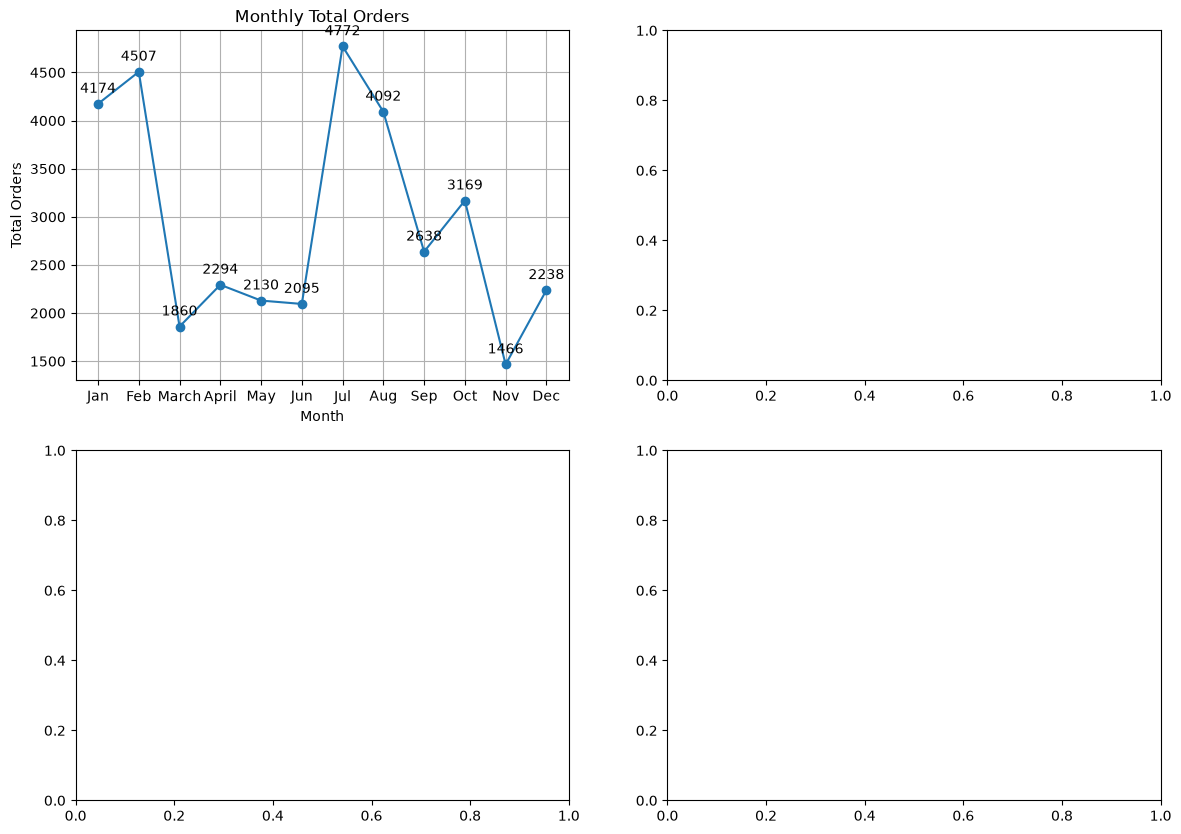

In [45]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# Subplot 1 : Total Orders

ax[0,0].plot(
    df["month"],
    df["total_orders"],
    marker="o"
)

for i, value in enumerate(df["total_orders"]):
    ax[0,0].annotate(
        value,
        (df["month"].iloc[i], value),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )
    
ax[0,0].set_title("Monthly Total Orders")
ax[0,0].set_xlabel("Month")
ax[0,0].set_ylabel("Total Orders")
ax[0,0].grid(True)



- Subplot 2 — Bar chart: Plot monthly revenue; 
colour each bar green if revenue exceeds Rs 8,00,000 and red otherwise, 
and draw a horizontal dashed line at the Rs 8,00,000 threshold.

In [47]:
# Subplot 2 : Monthly Revenue


threshold = 800000

# Green if revenue > 8,00,000, otherwise red
bar_colors = [
    "green" if revenue > threshold else "red"
    for revenue in df["monthly_revenue"]
]


ax[0,1].bar(
    df["month"],
    df["monthly_revenue"],
    color=bar_colors
)

# Horizontal threshold line
ax[0,1].axhline(
    y=threshold,
    linestyle="--",
    linewidth=2
)

ax[0,1].set_title("Monthly Revenue")
ax[0,1].set_xlabel("Month")
ax[0,1].set_ylabel("Revenue (₹)")
# ax[0,1].legend()
ax[0,1].grid(axis="y", alpha=0.3)

# plt.tight_layout()
plt.show()

- Subplot 3 — Histogram: Plot 500 simulated delivery times (use the generated mean and std) with 15 bins; add a vertical dashed line at the sample mean labelled 'Mean'

In [48]:
# Generate 500 delivery times
delivery_times = np.random.normal(
    loc=28,
    scale=4,
    size=500
)

# sample mean
sample_mean = np.mean(delivery_times)

# Histogram with 15 bins
ax[1,0].hist(
    delivery_times,
    bins=15
)

# mean
ax[1,0].axvline(
    sample_mean,
    linestyle="--",
    linewidth=2,
    label="Mean"
)

# Labels
ax[1,0].set_title("Distribution of Delivery Times")
ax[1,0].set_xlabel("Delivery Time (Minutes)")
ax[1,0].set_ylabel("Frequency")
ax[1, 0].grid(axis="y", alpha=0.3)

# Show mean in legend
# ax[1,0].legend()

# Display chart

# plt.show()

print(f"Sample Mean: {sample_mean:.2f} minutes")

Sample Mean: 28.27 minutes


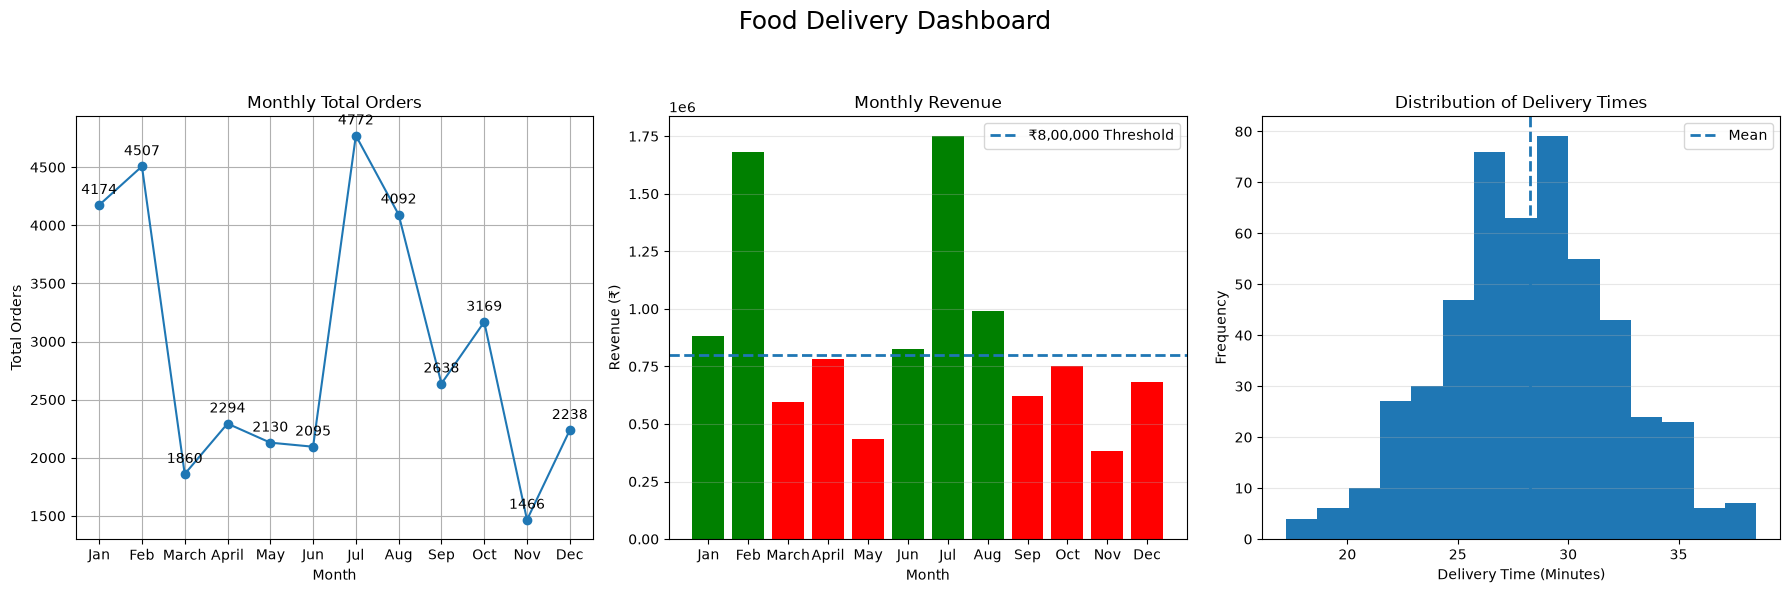

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# -----------------------------
# Plot 1
# -----------------------------
ax[0].plot(
    df["month"],
    df["total_orders"],
    marker="o"
)

for i, value in enumerate(df["total_orders"]):
    ax[0].annotate(
        value,
        (df["month"].iloc[i], value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

ax[0].set_title("Monthly Total Orders")
ax[0].set_xlabel("Month")
ax[0].set_ylabel("Total Orders")
ax[0].grid(True)


# -----------------------------
# Plot 2
# -----------------------------
threshold = 800000

bar_colors = [
    "green" if value > threshold else "red"
    for value in df["monthly_revenue"]
]

ax[1].bar(
    df["month"],
    df["monthly_revenue"],
    color=bar_colors
)

ax[1].axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label="₹8,00,000 Threshold"
)

ax[1].set_title("Monthly Revenue")
ax[1].set_xlabel("Month")
ax[1].set_ylabel("Revenue (₹)")
ax[1].legend()
ax[1].grid(axis="y", alpha=0.3)


# -----------------------------
# Plot 3
# -----------------------------
ax[2].hist(
    delivery_times,
    bins=15
)

ax[2].axvline(
    sample_mean,
    linestyle="--",
    linewidth=2,
    label="Mean"
)

ax[2].set_title("Distribution of Delivery Times")
ax[2].set_xlabel("Delivery Time (Minutes)")
ax[2].set_ylabel("Frequency")
ax[2].legend()
ax[2].grid(axis="y", alpha=0.3)


# -----------------------------
# Final dashboard
# -----------------------------
fig.suptitle(
    "Food Delivery Dashboard",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.savefig(
    "food_delivery_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()